In [145]:
import pandas as pd
import os
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [146]:
df = pd.read_csv('banco_fenotipos_conformal.csv')
df = df.replace(['Não respondeu', 'não respondeu', 'NAO RESPONDEU'], np.nan)

In [147]:
print(df.columns)

Index(['id', 'hb_g_dl', 'glicose_mg_dl', 'samplefilename', 'fumo', 'raca_cor',
       'conjugal3', 'trabalho2', 'bebem2', 'sexo', 'idade', 'faixa_etaria',
       'imc', 'imc_cat4_aferido', 'imc_cat_aferido', 'ep', 'obesidade', 'ccm',
       'obes_central', 'cc_estat', 'cc_estat_cat', 'medDM_bioq', 'diabetes2',
       'HOMA_IR', 'HOMA_cat', 'pas_final', 'pad_final', 'medHAS_bioq', 'has2',
       'col_nao_hdlc_mg_dl', 'colnaohdl_cat', 'CP1', 'CP2', 'CP3', 'CP4',
       'CP5', 'CP6'],
      dtype='object')


In [148]:
CATEGORICAS = ['fumo','raca_cor','conjugal3', 'trabalho2', 'bebem2', 'sexo','faixa_etaria', 'imc_cat4_aferido', 'imc_cat_aferido', 'ep', 'obesidade','obes_central','medDM_bioq', 'diabetes2','HOMA_cat','medHAS_bioq','has2','colnaohdl_cat']

In [149]:
dfcat = df[CATEGORICAS]

# Preparacao para graficos e analises

In [150]:
# Ajustando sexo

mapeamento = {
    1: 'Masculino',
    2: 'Feminino'
}
dfcat['sexo'] = dfcat['sexo'].map(mapeamento)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_4904\1994704585.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfcat['sexo'] = dfcat['sexo'].map(mapeamento)


In [151]:
def resumo_categoricas(df, coluna):
    print('Distribuicao de frequencias absolutas e relativas para a coluna:', coluna,'\n')
    display(dfcat[coluna].value_counts())
    display((dfcat[coluna].value_counts(normalize=True) * 100).round(2))
    print(f"Valor absoluto e porcentagem de dados nulos em '{coluna}': {dfcat[coluna].isnull().sum()} ({dfcat[coluna].isnull().mean() * 100:.2f}%)")
    chi2, p, dof, expected = chi2_contingency(pd.crosstab(dfcat[coluna], dfcat['diabetes2']))
    print(f"P-Valor para associação entre '{coluna}' e 'diabetes2': {p:.4f}")

In [152]:
def plot_pizza(df, coluna):
    dados_pizza = df[coluna].value_counts()
    cores = sns.color_palette('hls', len(dados_pizza))
    
    plt.figure(figsize=(8, 6))
    plt.pie(dados_pizza, 
            labels=dados_pizza.index, 
            autopct='%1.1f%%',  
            startangle=90,
            colors=cores,            
            shadow=True)             
    
    plt.title(f'Proporção Geral da Variável {coluna.capitalize()}')
    plt.axis('equal')
    plt.show()

In [153]:
def plot_proporcao(df, var1, var2):
    proporcao = pd.crosstab(df[var1], df[var2], normalize='index')
    proporcao.plot(kind='bar', stacked=True, color=sns.color_palette('hls', len(proporcao.columns)))
    
    plt.title(f'Influência de {var1.capitalize()} em {var2.capitalize()} (Proporção)')
    plt.ylabel('Frequência Relativa')
    plt.xlabel(var1.capitalize())
    plt.legend(title=var2.capitalize(), bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [154]:
def plot_distribuicao(df, var1, var2):
    plt.figure(figsize=(8, 6))
    sns.countplot(x=var1, hue=var2, data=df, palette='hls')
    
    plt.title(f'Influência de {var1.capitalize()} em {var2.capitalize()} (Contagem)')
    plt.ylabel('Contagem')
    plt.xlabel(var1.capitalize())
    plt.legend(title=var2.capitalize(), bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Analise geral

In [155]:
# Calcula a porcentagem de nulos, ordena e arredonda
porcentagem_nulos = (df[CATEGORICAS].isnull().mean() * 100).sort_values(ascending=False).round(2)

print("Porcentagem de dados nulos por coluna (apenas com valores ausentes):")
porcentagem_nulos[porcentagem_nulos > 0]

Porcentagem de dados nulos por coluna (apenas com valores ausentes):


obes_central        30.28
imc_cat4_aferido    29.72
colnaohdl_cat        2.08
raca_cor             1.25
HOMA_cat             1.11
fumo                 0.69
has2                 0.56
diabetes2            0.42
ep                   0.28
imc_cat_aferido      0.28
obesidade            0.28
dtype: float64

In [156]:
tabela1 = []
for coluna in CATEGORICAS:
    contagem = df[coluna].value_counts()
    porcentagem = df[coluna].value_counts(normalize=True) * 100
    resumo = pd.DataFrame({'N': contagem, '%': porcentagem.round(1)})
    resumo['Variavel'] = coluna
    tabela1.append(resumo)
df_tabela1 = pd.concat(tabela1)
display(df_tabela1)

,N,%,Variavel
nunca,503,70.3,fumo
ex-fumante,125,17.5,fumo
fumante,87,12.2,fumo
branca,364,51.2,raca_cor
parda,231,32.5,raca_cor
preta,73,10.3,raca_cor
outras,31,4.4,raca_cor
amarela,10,1.4,raca_cor
indígena,2,0.3,raca_cor
casado/un. estavel,303,42.1,conjugal3


# Fumo

## Descricao

In [157]:
resumo_categoricas(dfcat, 'fumo')

Distribuicao de frequencias absolutas e relativas para a coluna: fumo 



fumo
nunca         503
ex-fumante    125
fumante        87
Name: count, dtype: int64

fumo
nunca         70.35
ex-fumante    17.48
fumante       12.17
Name: proportion, dtype: float64

Valor absoluto e porcentagem de dados nulos em 'fumo': 5 (0.69%)
P-Valor para associação entre 'fumo' e 'diabetes2': 0.0006


## Graficos

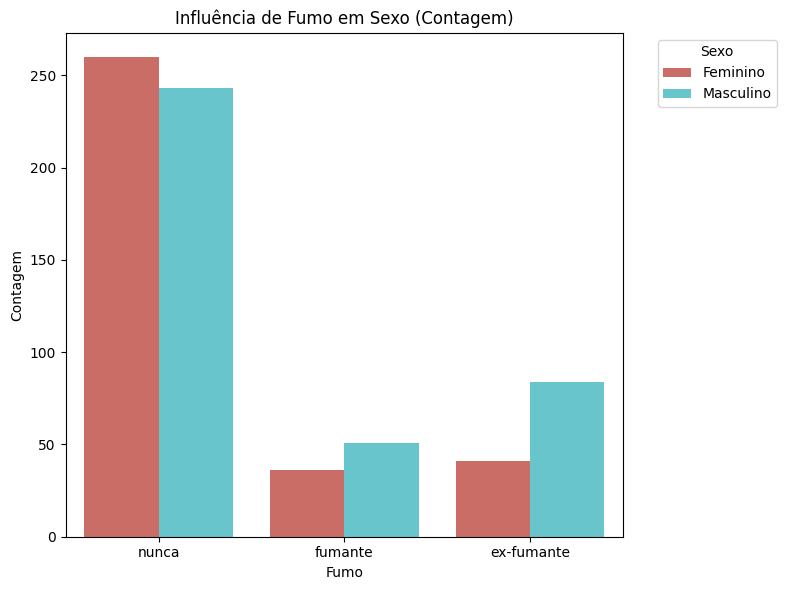

In [158]:
plot_distribuicao(dfcat, 'fumo', 'sexo')

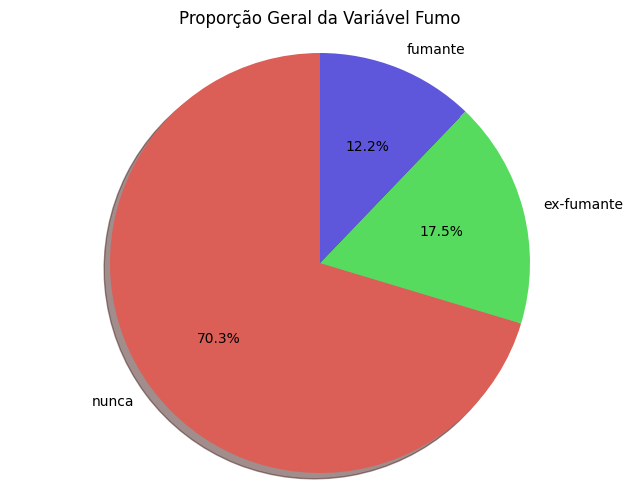

In [159]:
plot_pizza(dfcat, 'fumo')

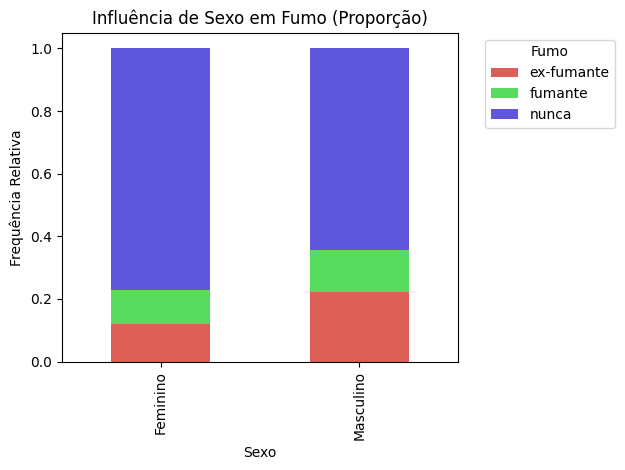

In [160]:
plot_proporcao(dfcat, 'sexo', 'fumo')

# Raca cor

## Descricao

In [161]:
resumo_categoricas(dfcat, 'raca_cor')

Distribuicao de frequencias absolutas e relativas para a coluna: raca_cor 



raca_cor
branca      364
parda       231
preta        73
outras       31
amarela      10
indígena      2
Name: count, dtype: int64

raca_cor
branca      51.20
parda       32.49
preta       10.27
outras       4.36
amarela      1.41
indígena     0.28
Name: proportion, dtype: float64

Valor absoluto e porcentagem de dados nulos em 'raca_cor': 9 (1.25%)
P-Valor para associação entre 'raca_cor' e 'diabetes2': 0.1718


## Graficos

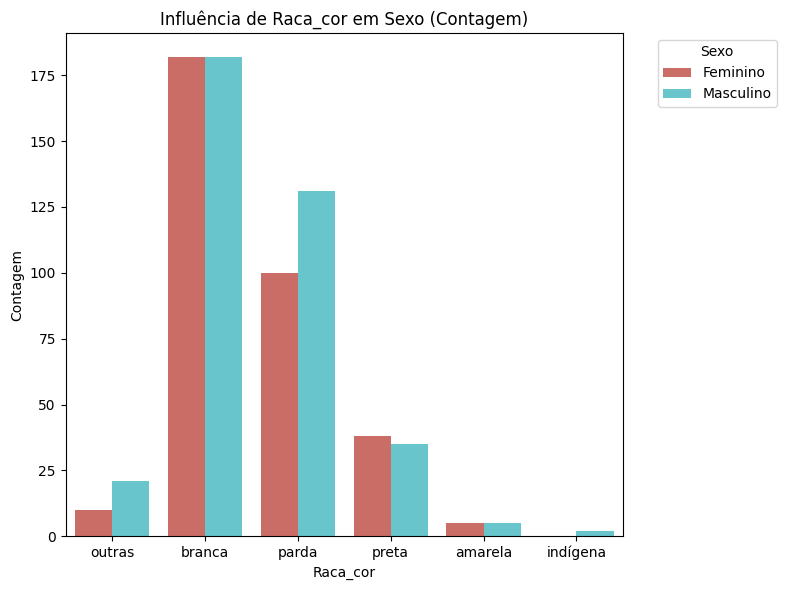

In [162]:
plot_distribuicao(dfcat, 'raca_cor', 'sexo')

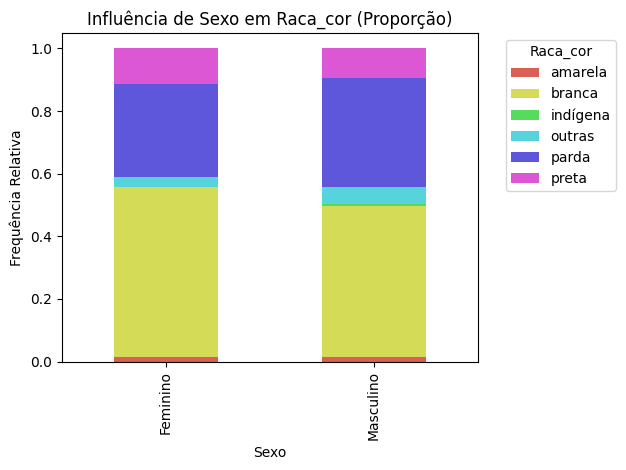

In [163]:
plot_proporcao(dfcat, 'sexo', 'raca_cor')

# Faixa Etaria

## Descricao

In [164]:
resumo_categoricas(dfcat, 'faixa_etaria')

Distribuicao de frequencias absolutas e relativas para a coluna: faixa_etaria 



faixa_etaria
2    280
1    227
0    213
Name: count, dtype: int64

faixa_etaria
2    38.89
1    31.53
0    29.58
Name: proportion, dtype: float64

Valor absoluto e porcentagem de dados nulos em 'faixa_etaria': 0 (0.00%)
P-Valor para associação entre 'faixa_etaria' e 'diabetes2': 0.0000


## Graficos

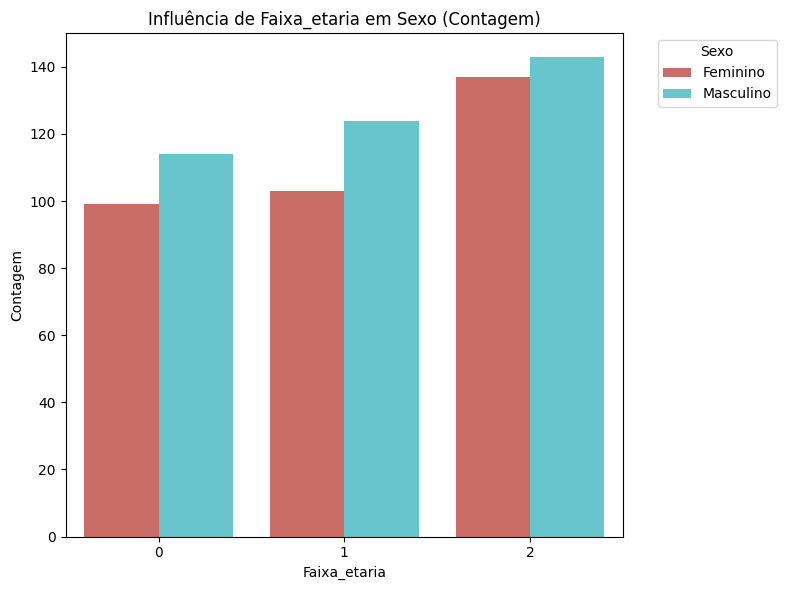

In [165]:
plot_distribuicao(dfcat, 'faixa_etaria', 'sexo')
# 0=adolescentes (0-19 anos); 1=adultos (20-59 anos); 2=idosos (60 anos ou mais)

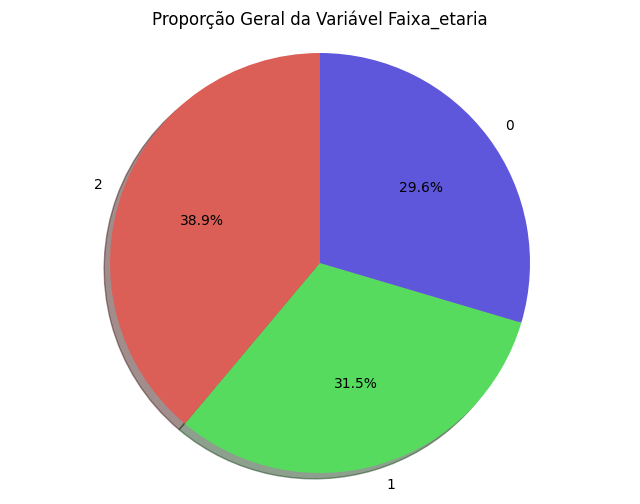

In [166]:
plot_pizza(dfcat, 'faixa_etaria')
# 0=adolescentes (0-19 anos); 1=adultos (20-59 anos); 2=idosos (60 anos ou mais)

# Bebem

## Descricao

In [167]:
resumo_categoricas(dfcat, 'bebem2')

Distribuicao de frequencias absolutas e relativas para a coluna: bebem2 



bebem2
nÃ£o bebe             528
atÃ© 3x semana        136
NS/NR                  31
4 ou mais x semana     25
Name: count, dtype: int64

bebem2
nÃ£o bebe             73.33
atÃ© 3x semana        18.89
NS/NR                  4.31
4 ou mais x semana     3.47
Name: proportion, dtype: float64

Valor absoluto e porcentagem de dados nulos em 'bebem2': 0 (0.00%)
P-Valor para associação entre 'bebem2' e 'diabetes2': 0.4842


## Graficos

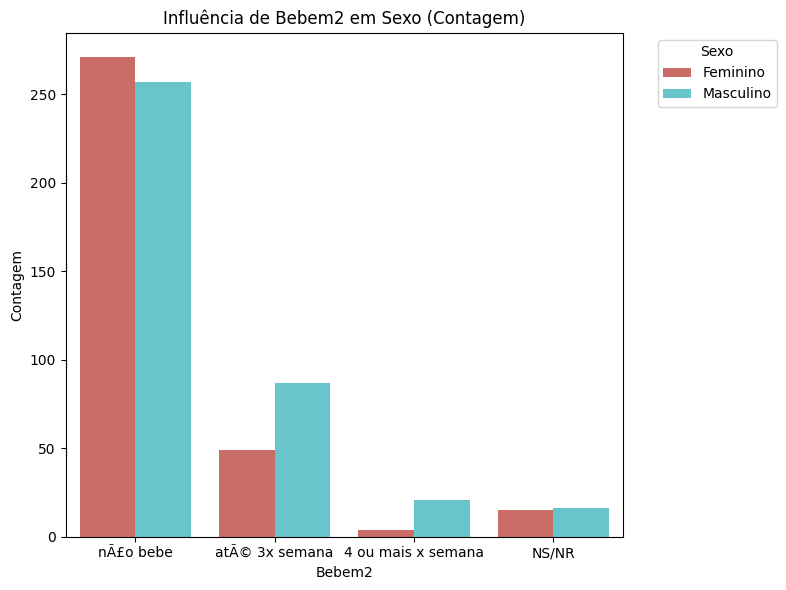

In [168]:
plot_distribuicao(dfcat, 'bebem2', 'sexo')

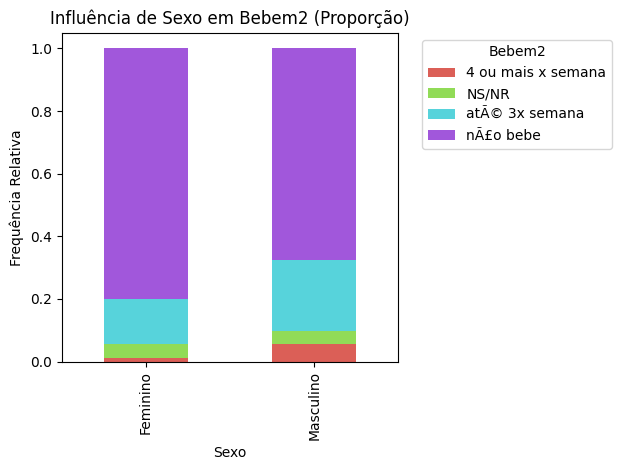

In [169]:
plot_proporcao(dfcat, 'sexo', 'bebem2')

# Conjugal

## Descricao

In [170]:
resumo_categoricas(dfcat, 'conjugal3')

Distribuicao de frequencias absolutas e relativas para a coluna: conjugal3 



conjugal3
casado/un. estavel      303
solteiro                280
viuvo                    76
separado/desq/divorc     55
NS/NR                     6
Name: count, dtype: int64

conjugal3
casado/un. estavel      42.08
solteiro                38.89
viuvo                   10.56
separado/desq/divorc     7.64
NS/NR                    0.83
Name: proportion, dtype: float64

Valor absoluto e porcentagem de dados nulos em 'conjugal3': 0 (0.00%)
P-Valor para associação entre 'conjugal3' e 'diabetes2': 0.0000


## Graficos

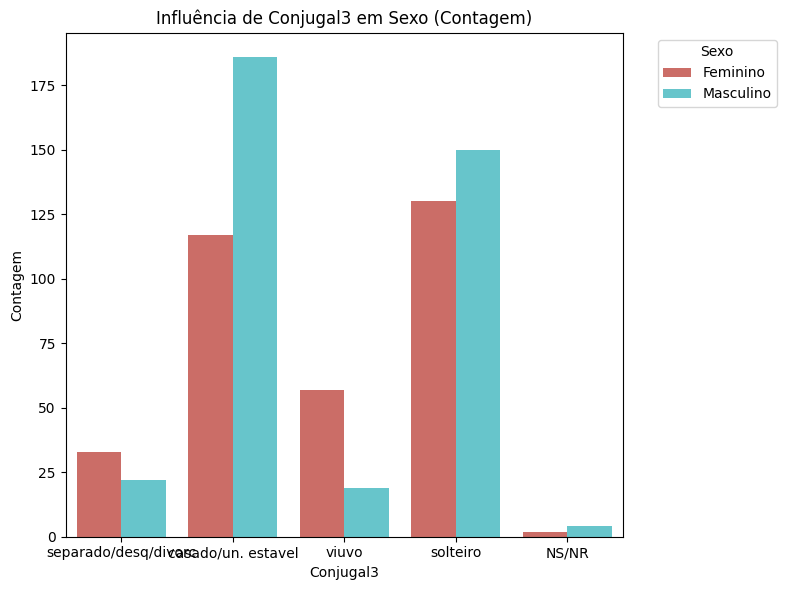

In [171]:
plot_distribuicao(dfcat, 'conjugal3', 'sexo')

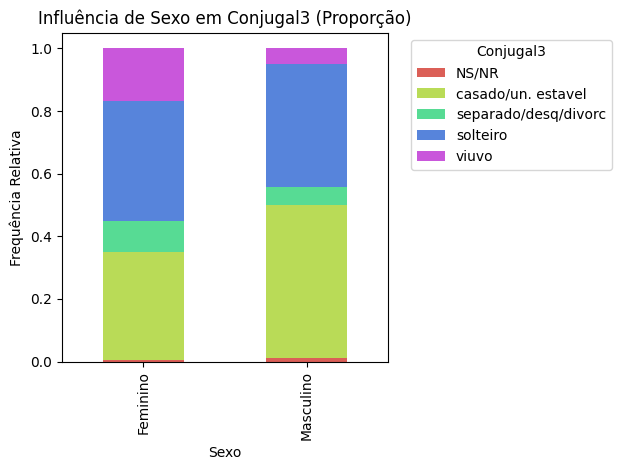

In [172]:
plot_proporcao(dfcat, 'sexo', 'conjugal3')

# Trabalho

## Descricao

In [173]:
resumo_categoricas(dfcat, 'trabalho2')

Distribuicao de frequencias absolutas e relativas para a coluna: trabalho2 



trabalho2
trabalha         304
nÃ£o trabalha    242
estudante        163
Outro/NS/NR       11
Name: count, dtype: int64

trabalho2
trabalha         42.22
nÃ£o trabalha    33.61
estudante        22.64
Outro/NS/NR       1.53
Name: proportion, dtype: float64

Valor absoluto e porcentagem de dados nulos em 'trabalho2': 0 (0.00%)
P-Valor para associação entre 'trabalho2' e 'diabetes2': 0.0000


## Graficos

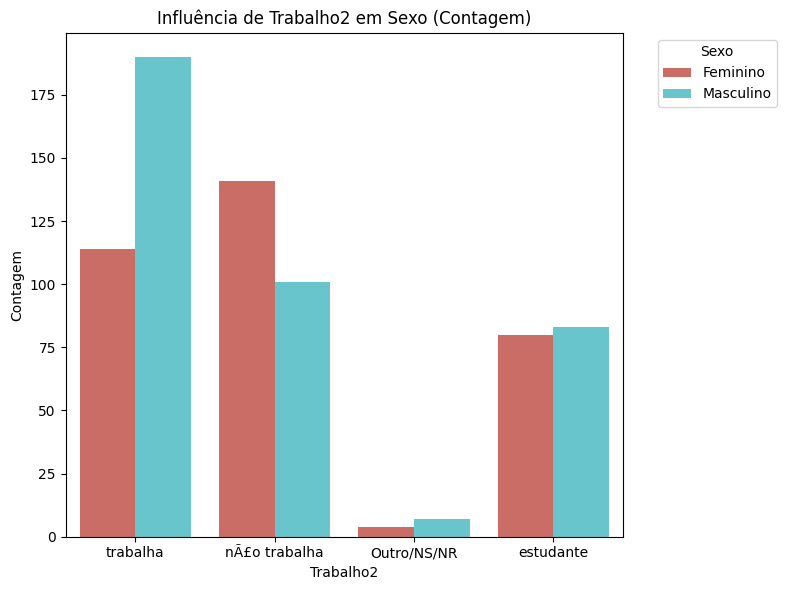

In [174]:
plot_distribuicao(dfcat,'trabalho2','sexo')

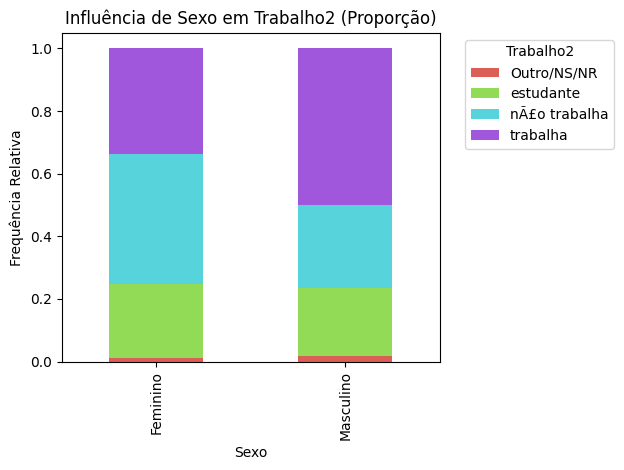

In [175]:
plot_proporcao(dfcat,'sexo','trabalho2')

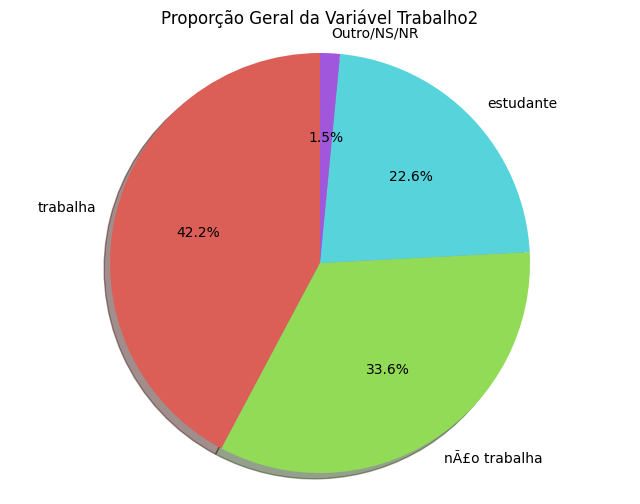

In [176]:
plot_pizza(dfcat, 'trabalho2')